<a href="https://colab.research.google.com/github/Churrascooo/Practica-1/blob/main/CODIGOFINAL/Fase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explicación de la fase

Esta es la fase 3, la cual contiene 3 tareas principales: ***identificación de comorbilidades predominantes, fusión de notas clínicas y modelado de supervivencia (Kaplan-Meier).***

A continuación se explicará lo que hace cada tarea, para mayor comprensión de esta fase.

- **Identificación de comorbilidades predominantes:** Se buscan las enfermedades más comúnes dentro de la cohorte. Estas enfermedades vienen acompañads con su código ICD.

- **Fusión de notas clínicas:** A todos los pacientes que hayan ingresado a hospitalización en las primeras 48 horas y tengan notas en **radiology**, se le unirá su **primera nota**. La idea de esto es que las notas aporten información de los pacientes.

- **Modelado de supervivencia:** En esta fase se generan curvas de supervivencia de Kaplan–Meier estratificadas según la presencia o ausencia de las comorbilidades identificadas anteriormente. El análisis considera el tiempo desde el ingreso hospitalario hasta la muerte intrahospitalaria o el alta (censura).
La idea de esto es ver cuándo ocurre el evento y cómo cambia ese tiempo según las comorbilidades.

# Importación y cargado de herramientas necesarias

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install scikit-survival
from sksurv.nonparametric import kaplan_meier_estimator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

OUT_DIR = "/content/drive/MyDrive/mimic_outputs"
RAW_DIR = "/content/drive/MyDrive" #Donde están los csv de MIMIC
NOTES_DIR = "/content/drive/MyDrive"

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 17.2 MB/s eta 0:00:00


In [ ]:
#Inputs del pipeline
base_patient = pd.read_parquet(os.path.join(OUT_DIR, "cohort_hosp_60.parquet"))
patient_history = pd.read_parquet(os.path.join(OUT_DIR, "patient_history.parquet"))
dx_clean = pd.read_parquet(os.path.join(OUT_DIR, "dx_clean_index.parquet"))

radiology = pd.read_csv(
    os.path.join(RAW_DIR, "radiology.csv.gz"),
    compression="gzip",
    usecols=["subject_id", "hadm_id", "charttime", "text"]
)

base_keys = base_patient[["subject_id", "hadm_id", "admittime"]].copy()
base_keys["admittime"] = pd.to_datetime(base_keys["admittime"], errors="coerce")
radiology["charttime"] = pd.to_datetime(radiology["charttime"], errors="coerce")

#Verificación rápida
print(base_patient.shape)
print(patient_history.shape)

(111122, 11)
(111122, 18)


In [ ]:
#Comprueba que un DataFrame tenga exactamente una fila por paciente (subject_id)
#Si hay duplicados, lanza un error para detener el pipeline
def check_unique(df, key="subject_id", name="df"):
    n_rows = len(df) #Número total de filas
    n_uniq = df[key].nunique(dropna=False) #Número de IDs únicos
    print(f"[{name}] filas={n_rows:,} | {key} únicos={n_uniq:,}")

    #1 fila = 1 paciente
    assert n_rows == n_uniq, (
        f"{name} NO es 1 fila por {key}. "
        f"Duplicados: {n_rows - n_uniq:,}"
    )
    print(f"OK: {name} es 1 fila por {key}\n")

# Identificación de comorbilidades predominantes

In [ ]:
#Conteo de diagnósticos (Top 5)
dx_counts = (
    dx_clean.groupby(["icd_code", "long_title"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top5_comorbidities = dx_counts.head(5).copy()

print("Top 5 comorbilidades:")
top5_comorbidities

Top 5 comorbilidades:


,icd_code,long_title,count
6531,E785,"Hyperlipidemia, unspecified",32078
8444,I10,Essential (primary) hypertension,29671
1832,4019,Unspecified essential hypertension,22361
17915,Z87891,Personal history of nicotine dependence,21242
9665,K219,Gastro-esophageal reflux disease without esoph...,16664


In [ ]:
#Guardar Top 5
top5_comorbidities.to_parquet(
    os.path.join(OUT_DIR, "top5_comorbidities.parquet"),
    index=False
)

print("Top 5 comorbilidades guardadas en:", OUT_DIR)

Top 5 comorbilidades guardadas en: /content/drive/MyDrive/mimic_outputs


In [ ]:
#Flags Top 5 por paciente (1 fila por subject_id)
top5 = top5_comorbidities.copy()
top5["icd_code"] = top5["icd_code"].astype(str)
top5_codes = top5["icd_code"].tolist()

print("Top5 icd_code:", top5_codes)

dx_tmp = dx_clean.copy()
dx_tmp["icd_code"] = dx_tmp["icd_code"].astype(str)

#Presencia (0/1) por paciente y código del top 5
dx_top5_presence = (
    dx_tmp[dx_tmp["icd_code"].isin(top5_codes)][["subject_id", "icd_code"]]
    .drop_duplicates()
    .assign(value=1)
)

#Pivote a ancho, 1 fila por subject_id, columnas = icd_code
flags_top5_patient = (
    dx_top5_presence
    .pivot_table(
        index="subject_id",
        columns="icd_code",
        values="value",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

#Se asegura que existan todas las columnas del top5 (aunque alguna no aparezca)
for code in top5_codes:
    if code not in flags_top5_patient.columns:
        flags_top5_patient[code] = 0

print("flags_top5_patient:", flags_top5_patient.shape)
check_unique(flags_top5_patient, key="subject_id", name="flags_top5_patient")

flags_top5_patient.head()

Top5 icd_code: ['E785', 'I10', '4019', 'Z87891', 'K219']
flags_top5_patient: (76654, 6)
[flags_top5_patient] filas=76,654 | subject_id únicos=76,654
OK: flags_top5_patient es 1 fila por subject_id



icd_code,subject_id,4019,E785,I10,K219,Z87891
0,10000084,0,1,0,0,0
1,10000635,0,0,1,0,0
2,10000764,1,0,0,0,0
3,10000947,0,1,1,0,0
4,10000980,0,1,0,0,0


In [ ]:
#Integración final comorbilidades (1 fila por subject_id)
patient_comorb = base_patient[["subject_id"]].merge(
    flags_top5_patient,
    on="subject_id",
    how="left",
    validate="one_to_one"
)

#Rellenar NaN como 0 (no presenta comorbilidad)
for code in top5_codes:
    patient_comorb[code] = patient_comorb[code].fillna(0).astype(int)

print("patient_comorb:", patient_comorb.shape)
check_unique(patient_comorb, key="subject_id", name="patient_comorb")

patient_comorb.head()

patient_comorb: (111122, 6)
[patient_comorb] filas=111,122 | subject_id únicos=111,122
OK: patient_comorb es 1 fila por subject_id



,subject_id,4019,E785,I10,K219,Z87891
0,10000084,0,1,0,0,0
1,10000161,0,0,0,0,0
2,10000635,0,0,1,0,0
3,10000690,0,0,0,0,0
4,10000764,1,0,0,0,0


In [ ]:
#Guardar outputs
patient_comorb.to_parquet(
    os.path.join(OUT_DIR, "patient_comorb_top5.parquet"),
    index=False
)

flags_top5_patient.to_parquet(
    os.path.join(OUT_DIR, "flags_top5_patient.parquet"),
    index=False
)

print("Fase 3 guardada en:", OUT_DIR)

Fase 3 guardada en: /content/drive/MyDrive/mimic_outputs


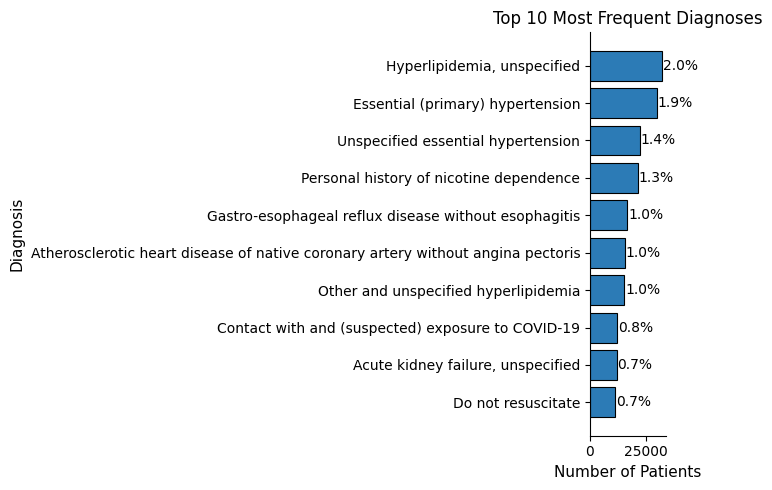

In [ ]:
#Top 10 comorbilidades más frecuentes
top10 = dx_counts.head(10).sort_values("count", ascending=True)
total = dx_counts["count"].sum()
percentages = top10["count"] / total * 100

#Crear figura tamaño paper
plt.figure(figsize=(7,5))

#Dibujar barras horizontales con estilo sobrio
bars = plt.barh(
    top10["long_title"],
    top10["count"],
    color="#2C7BB6",
    edgecolor="black",
    linewidth=0.8
)

#Quitar bordes superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#Agregar porcentaje al final de cada barra
for bar, pct in zip(bars, percentages):
    width = bar.get_width()
    plt.text(
        width + max(top10["count"])*0.01,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        ha="left",
        va="center",
        fontsize=10
    )

#Configuración del gráfico
plt.xlabel("Number of Patients", fontsize=11)
plt.ylabel("Diagnosis", fontsize=11)
plt.title(
    "Top 10 Most Frequent Diagnoses",
    fontsize=12
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("top10_diagnoses.pdf", bbox_inches="tight", facecolor="white")
plt.show()

# Fusión de notas clínicas

In [ ]:
#Vincular notas a cohorte índice (SIN filtro temporal sobre la nota)

#Asegurar que charttime sea datetime
radiology["charttime"] = pd.to_datetime(radiology["charttime"], errors="coerce")

#Quedarse solo con columnas necesarias de radiology
rad_base = radiology[["hadm_id", "charttime", "text"]].copy()

#Vincular SOLO hospitalización índice y traer subject_id desde base_keys
rad_all = rad_base.merge(
    base_keys[["subject_id", "hadm_id"]],
    on="hadm_id",
    how="inner",
    validate="many_to_one" #base_keys tiene 1 fila por hadm_id
)

print("rad_all (solo cohorte índice, ALL TIME):", rad_all.shape)

#Ordenar por paciente y tiempo
rad_all = rad_all.sort_values(["subject_id", "charttime"])

#Vista rápida
rad_all[["subject_id", "hadm_id", "charttime"]].head()

rad_all (solo cohorte índice, ALL TIME): (299995, 4)


,subject_id,hadm_id,charttime
0,10000084,29888819.0,2160-12-28 00:06:00
1,10000764,27897940.0,2132-10-15 09:02:00
2,10000980,20897796.0,2193-08-15 08:52:00
3,10000980,20897796.0,2193-08-15 19:28:00
4,10001176,23334588.0,2186-11-29 01:04:00


In [ ]:
#Nota única (PRIMERA disponible por paciente, ALL TIME)

#Ordenar por paciente y tiempo
rad_all_sorted = rad_all.sort_values(["subject_id", "charttime"]).copy()

#Tomar la PRIMERA nota disponible por paciente
first_note_anytime = (
    rad_all_sorted
    .groupby("subject_id", as_index=False)
    .first()[["subject_id", "charttime", "text"]]
    .rename(columns={
        "charttime": "note_time_single",
        "text": "notes_first_single"
    })
)

print("first_note_anytime:", first_note_anytime.shape)
check_unique(first_note_anytime, key="subject_id", name="first_note_anytime")

#Unir con todos los pacientes (los que no tienen nota quedan como NaN)
patient_notes_single = base_patient[["subject_id"]].merge(
    first_note_anytime,
    on="subject_id",
    how="left",
    validate="one_to_one"
)

check_unique(patient_notes_single, key="subject_id", name="patient_notes_single")

#Cálculo correcto de largo de texto (NaN -> 0)
patient_notes_single["n_chars_single"] = (
    patient_notes_single["notes_first_single"]
    .fillna("")
    .astype(str)
    .str.len()
)

#Resumen de largos
patient_notes_single["n_chars_single"].describe()

#Cobertura real
has_single = patient_notes_single["n_chars_single"] > 0
print(
    f"Pacientes con PRIMERA nota (ALL TIME): "
    f"{has_single.sum():,} / {len(patient_notes_single):,} "
    f"({has_single.mean():.1%})"
)

first_note_anytime: (63763, 3)
[first_note_anytime] filas=63,763 | subject_id únicos=63,763
OK: first_note_anytime es 1 fila por subject_id

[patient_notes_single] filas=111,122 | subject_id únicos=111,122
OK: patient_notes_single es 1 fila por subject_id

Pacientes con PRIMERA nota (ALL TIME): 63,763 / 111,122 (57.4%)


In [ ]:
#Esto corresponde a las notas únicas (PRIMERA nota disponible, ALL TIME)

patient_notes_single[
    patient_notes_single["n_chars_single"] > 0
][["subject_id", "note_time_single", "notes_first_single"]].head()

,subject_id,note_time_single,notes_first_single
0,10000084,2160-12-28 00:06:00,EXAMINATION: CT HEAD W/O CONTRAST Q111 CT HEA...
4,10000764,2132-10-15 09:02:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
6,10000980,2193-08-15 08:52:00,EXAMINATION: BILAT LOWER EXT VEINS\n\nINDICAT...
7,10001176,2186-11-29 01:04:00,"HISTORY: ___ female with fevers, nausea, vomi..."
9,10001492,2136-09-23 13:13:00,SINGLE VIEW OF THE CHEST ___\n\nHISTORY: ___ ...


In [ ]:
#Guardar notas clínicas (PRIMERA nota disponible por paciente, ALL TIME)

OUT_NOTES_SINGLE = os.path.join(OUT_DIR, "patient_notes_first_single.parquet")

patient_notes_single.drop(
    columns=["n_chars_single"],
    errors="ignore"
).to_parquet(
    OUT_NOTES_SINGLE,
    index=False
)

print("Notas clínicas guardadas:")
print(" -", OUT_NOTES_SINGLE)

Notas clínicas guardadas:
 - /content/drive/MyDrive/mimic_outputs/patient_notes_first_single.parquet


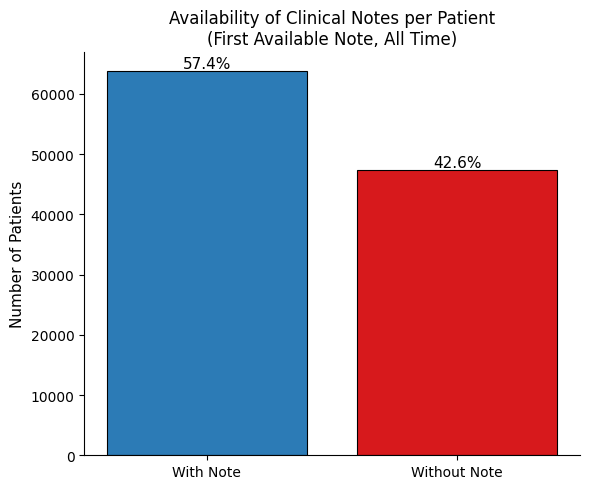

In [ ]:
#Calcular conteos de pacientes con y sin nota
with_note = (patient_notes_single["n_chars_single"] > 0).sum()
without_note = (patient_notes_single["n_chars_single"] == 0).sum()
total = with_note + without_note

labels = ["With Note", "Without Note"]
values = [with_note, without_note]
percentages = [v / total * 100 for v in values]

#Crear figura tamaño paper
plt.figure(figsize=(6,5))

#Dibujar barras con estilo sobrio
bars = plt.bar(
    labels,
    values,
    color=["#2C7BB6", "#D7191C"],
    edgecolor="black",
    linewidth=0.8
)

#Quitar bordes superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Agregar porcentaje sobre cada barra
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

#Configuración del gráfico
plt.title(
    "Availability of Clinical Notes per Patient\n(First Available Note, All Time)",
    fontsize=12
)
plt.ylabel("Number of Patients", fontsize=11)
plt.xlabel("")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("clinical_notes_availability.pdf", bbox_inches="tight", facecolor="white")
plt.show()

# Modelado de supervivencia (Kaplan-Meier)

In [ ]:
#Dataset de supervivencia (1 fila por subject_id)
surv_patient = base_patient[
    ["subject_id", "admittime", "dischtime", "deathtime", "hospital_expire_flag"]
].copy()

for c in ["admittime", "dischtime", "deathtime"]:
    surv_patient[c] = pd.to_datetime(surv_patient[c], errors="coerce")

#Evento, muerte intrahospitalaria (1) vs censura (0)
surv_patient["event"] = surv_patient["hospital_expire_flag"].fillna(0).astype(int)

#Endtime, muerte si ocurrió, si no es alta
surv_patient["endtime"] = surv_patient["deathtime"].where(
    surv_patient["event"] == 1,
    surv_patient["dischtime"]
)

#Tiempo hasta evento/censura en días
surv_patient["time_days"] = (
    surv_patient["endtime"] - surv_patient["admittime"]
).dt.total_seconds() / (3600 * 24)

#Filtrar casos inválidos
surv_patient = surv_patient[
    surv_patient["time_days"].notna() & (surv_patient["time_days"] >= 0)
].copy()

print("surv_patient:", surv_patient.shape)
check_unique(surv_patient, key="subject_id", name="surv_patient")
surv_patient[["event", "time_days"]].describe()

surv_patient: (111090, 8)
[surv_patient] filas=111,090 | subject_id únicos=111,090
OK: surv_patient es 1 fila por subject_id



,event,time_days
count,111090.000000,111090.000000
mean,0.084067,5.731583
std,0.277489,7.891063
min,0.000000,0.000000
25%,0.000000,1.618056
50%,0.000000,3.603472
75%,0.000000,6.853472
max,1.000000,248.448611


In [ ]:
#Unir comorbilidades Top 5

#top5_codes y code_to_title vienen desde Fase 3
top5 = top5_comorbidities.copy()
top5["icd_code"] = top5["icd_code"].astype(str)
top5_codes = top5["icd_code"].tolist()

code_to_title = top5.set_index("icd_code")["long_title"].to_dict()

km_df = surv_patient.merge(
    patient_comorb,
    on="subject_id",
    how="left",
    validate="one_to_one"
)

#Asegurar columnas top5 como 0/1
for code in top5_codes:
    if code not in km_df.columns:
        km_df[code] = 0
    km_df[code] = km_df[code].fillna(0).astype(int)

print("km_df:", km_df.shape)
check_unique(km_df, key="subject_id", name="km_df")
km_df[["subject_id", "event", "time_days"] + top5_codes].head()

km_df: (111090, 13)
[km_df] filas=111,090 | subject_id únicos=111,090
OK: km_df es 1 fila por subject_id



,subject_id,event,time_days,E785,I10,4019,Z87891,K219
0,10000084,0,0.455556,1,0,0,0,0
1,10000161,0,0.618750,0,0,0,0,0
2,10000635,0,0.914583,0,1,0,0,0
3,10000690,0,1.677778,0,0,0,0,0
4,10000764,0,4.707639,0,0,1,0,0


In [ ]:
#Guardar dataset final

km_df.to_parquet(
    os.path.join(OUT_DIR, "km_df_top5.parquet"),
    index=False
)

#Printeo de confirmación
print("km_df_top5.parquet guardado en:", OUT_DIR)

km_df_top5.parquet guardado en: /content/drive/MyDrive/mimic_outputs


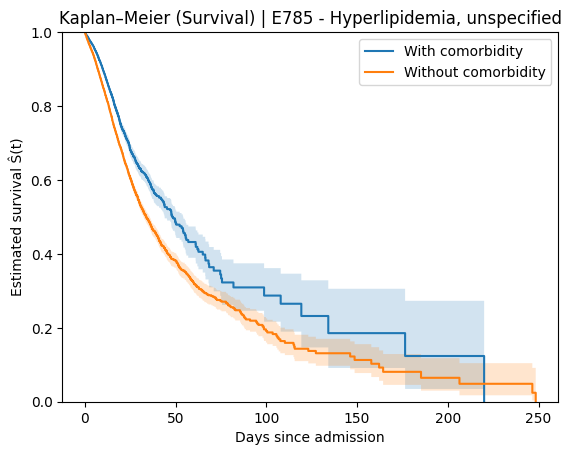

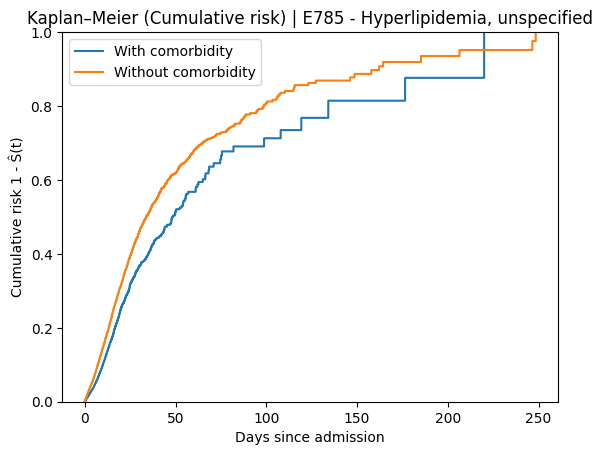

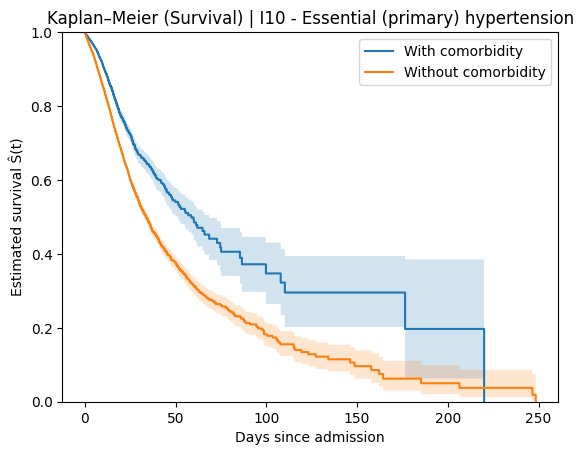

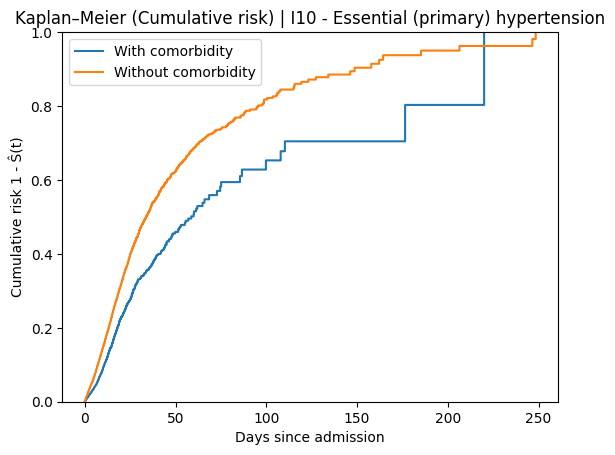

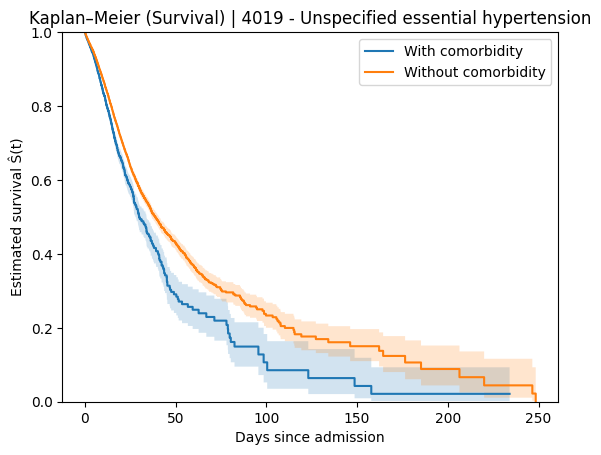

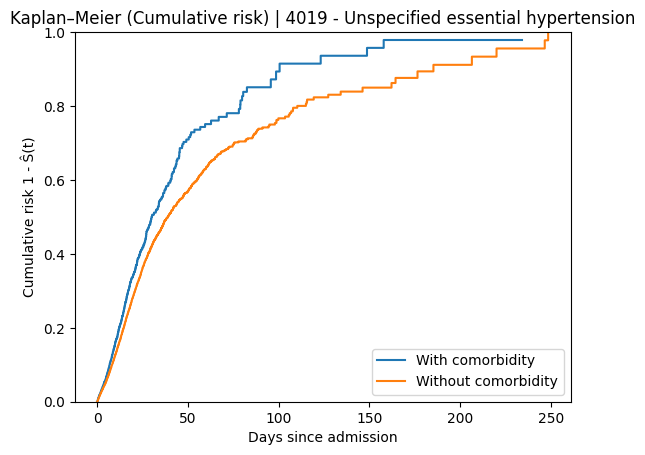

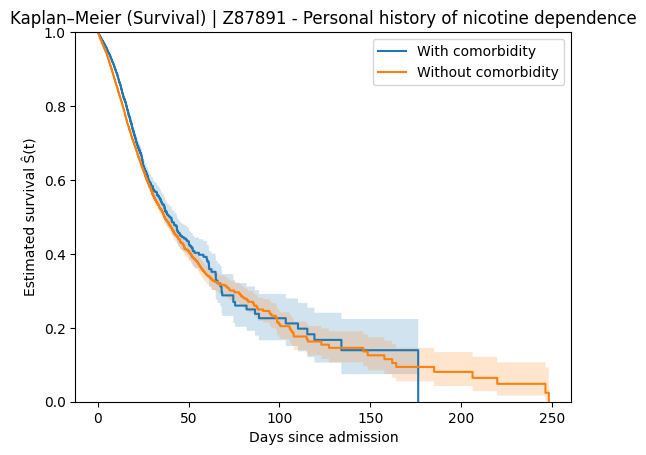

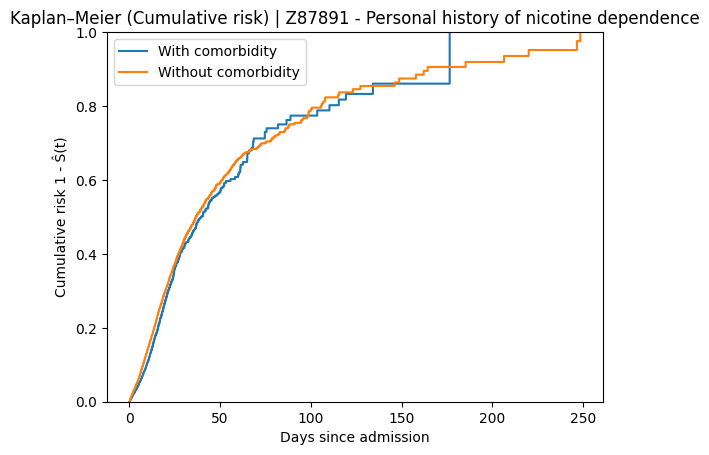

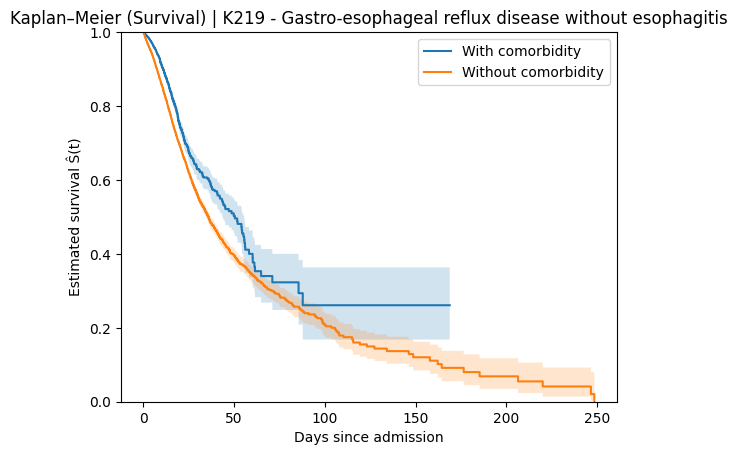

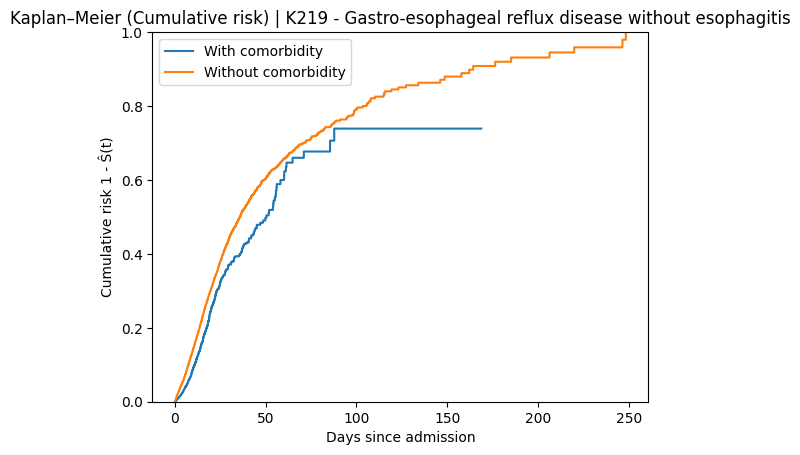

In [ ]:
#Kaplan–Meier por comorbilidad (Top5)

#Se itera sobre cada código ICD correspondiente a las 5 comorbilidades más frecuentes
for code in top5_codes:

    #Grupo de pacientes CON la comorbilidad (flag = 1)
    g1 = km_df[km_df[code] == 1]

    #Grupo de pacientes SIN la comorbilidad (flag = 0)
    g0 = km_df[km_df[code] == 0]

    #Si alguno de los grupos está vacío, no se puede estimar la curva
    if len(g1) == 0 or len(g0) == 0:
        print(f"Saltado {code}: grupo vacío (con={len(g1)}, sin={len(g0)})")
        continue

    #Estimación Kaplan–Meier para pacientes CON la comorbilidad
    #event: indica si ocurrió el evento (muerte intrahospitalaria)
    #time_days: tiempo hasta evento o censura
    #conf_type="log-log": intervalos de confianza estándar para KM
    t1, s1, ci1 = kaplan_meier_estimator(
        g1["event"].astype(bool),
        g1["time_days"],
        conf_type="log-log"
    )

    #Estimación Kaplan–Meier para pacientes SIN la comorbilidad
    t0, s0, ci0 = kaplan_meier_estimator(
        g0["event"].astype(bool),
        g0["time_days"],
        conf_type="log-log"
    )

    #Título del gráfico
    title = f"{code} - {code_to_title.get(code, '')}"

    plt.figure()
    plt.step(t1, s1, where="post", label="With comorbidity")
    plt.step(t0, s0, where="post", label="Without comorbidity")
    plt.fill_between(t1, ci1[0], ci1[1], alpha=0.2, step="post")
    plt.fill_between(t0, ci0[0], ci0[1], alpha=0.2, step="post")
    plt.ylim(0, 1)
    plt.xlabel("Days since admission")
    plt.ylabel("Estimated survival Ŝ(t)")
    plt.title(f"Kaplan–Meier (Survival) | {title}")
    plt.legend()
    plt.show()

    #El riesgo acumulado se define como 1 - Ŝ(t)
    plt.figure()
    plt.step(t1, 1 - s1, where="post", label="With comorbidity")
    plt.step(t0, 1 - s0, where="post", label="Without comorbidity")
    plt.ylim(0, 1)
    plt.xlabel("Days since admission")
    plt.ylabel("Cumulative risk 1 - Ŝ(t)")
    plt.title(f"Kaplan–Meier (Cumulative risk) | {title}")
    plt.legend()
    plt.show()